# Machine Learning Experiment Number 3

**Name:** Om Milind Retharekar   
           
**Roll no.:** CS46

**Class:** BE CSE

**Batch:** CS03

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [24]:
# Import NumPy for numerical calculations and matrix operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

# Display a message to confirm successful import
print("NumPy and Matplotlib imported successfully.")

NumPy and Matplotlib imported successfully.


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [25]:
import pandas as pd

# Load the CarDekho dataset
df = pd.read_csv("cardekho_dataset.csv")

# Display the first 5 records
print("First 5 records of the dataset:")
display(df.head())

# Display number of rows and columns
print("\nNumber of rows and columns:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Display all column names
print("\nAttributes in the dataset:")
print(df.columns.tolist())

# Identify numerical attributes
numerical_attributes = df.select_dtypes(include=np.number).columns.tolist()

# Identify categorical attributes
categorical_attributes = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Attributes:")
print(numerical_attributes)

print("\nCategorical Attributes:")
print(categorical_attributes)

# Separate selling_price as the target variable
y = df["selling_price"]

# Store remaining attributes as input features
X = df.drop("selling_price", axis=1)

print("\nTarget Variable:")
print("selling_price")

print("\nShape of Input Features (X):", X.shape)
print("Shape of Target Variable (y):", y.shape)

First 5 records of the dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows and columns:
Rows: 15411
Columns: 14

Attributes in the dataset:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical Attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical Attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target Variable:
selling_price

Shape of Input Features (X): (15411, 13)
Shape of Target Variable (y): (15411,)


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [26]:
# Check the number of missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Calculate the total number of missing values
total_missing = df.isnull().sum().sum()

print("\nTotal missing values:", total_missing)

# Handle missing values if they are present
if total_missing > 0:
    # Remove records containing missing values
    df = df.dropna()
    print("\nMissing records have been removed.")
else:
    print("\nNo missing values are present. No imputation or removal is required.")

# Verify that the final dataset contains no missing values
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nTotal missing values after preprocessing:", df.isnull().sum().sum())

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

No missing values are present. No imputation or removal is required.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values after preprocessing: 0


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [27]:
# Display all available attributes
print("Available Attributes:")
print(df.columns.tolist())

# Select meaningful numerical predictor variables
selected_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Car_Name is not selected because it is a categorical text attribute
# and is not directly suitable for numerical regression.

# Create predictor matrix X
X = df[selected_features]

# Create target vector y
y = df["selling_price"]

# Display the selected features
print("\nFinal Features Selected:")
print(selected_features)

print("\nShape of Predictor Matrix X:", X.shape)
print("Shape of Target Vector y:", y.shape)

Available Attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Final Features Selected:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Shape of Predictor Matrix X: (15411, 6)
Shape of Target Vector y: (15411,)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [28]:
# Identify the categorical variables
categorical_variables = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("Categorical Variables:")
print(categorical_variables)

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(
    X.join(df[categorical_variables]),
    columns=categorical_variables,
    drop_first=True
)

# Convert True/False dummy values into numerical 0/1 values
X = X.astype(int)

# Verify that all predictors are numerical
print("\nData Types After Encoding:")
print(X.dtypes)

# Display the transformed dataset
print("\nTransformed Dataset:")
display(X.head())

Categorical Variables:
['fuel_type', 'seller_type', 'transmission_type']

Data Types After Encoding:
vehicle_age                     int64
km_driven                       int64
mileage                         int64
engine                          int64
max_power                       int64
seats                           int64
fuel_type_Diesel                int64
fuel_type_Electric              int64
fuel_type_LPG                   int64
fuel_type_Petrol                int64
seller_type_Individual          int64
seller_type_Trustmark Dealer    int64
transmission_type_Manual        int64
dtype: object

Transformed Dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19,796,46,5,0,0,0,1,1,0,1
1,5,20000,18,1197,82,5,0,0,0,1,1,0,1
2,11,60000,17,1197,80,5,0,0,0,1,1,0,1
3,9,37000,20,998,67,5,0,0,0,1,1,0,1
4,6,30000,22,1498,98,5,1,0,0,0,0,0,1


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [29]:
# Create Car_Age using the existing vehicle_age column
df["Car_Age"] = df["vehicle_age"]

# Display several values of Car_Age
print("Sample values of Car_Age:")
display(df[["vehicle_age", "Car_Age"]].head(10))

# Check the minimum and maximum age
print("\nCar_Age range:")
print("Minimum Age:", df["Car_Age"].min())
print("Maximum Age:", df["Car_Age"].max())

Sample values of Car_Age:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Car_Age range:
Minimum Age: 0
Maximum Age: 29


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

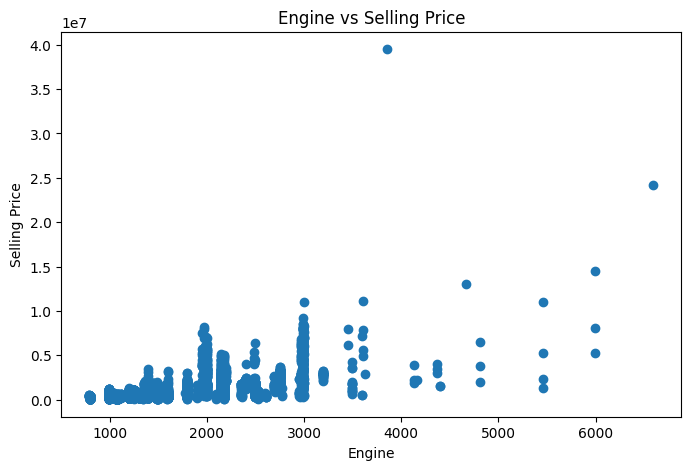

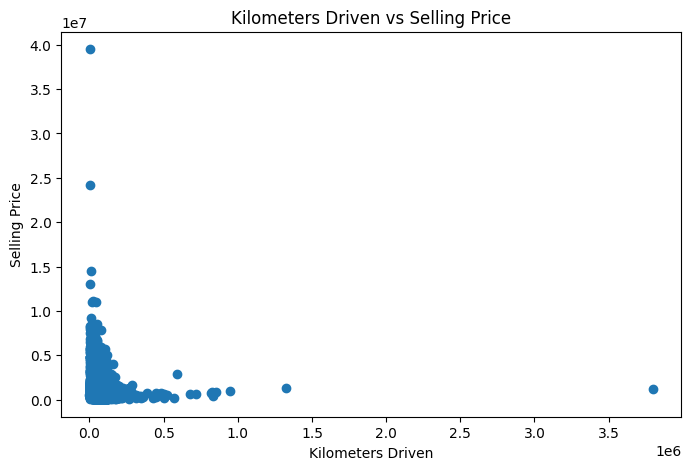

In [30]:
# Scatter plot of engine versus selling price
plt.figure(figsize=(8, 5))
plt.scatter(df["engine"], df["selling_price"])
plt.xlabel("Engine")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")
plt.show()

# Scatter plot of km_driven versus selling price
plt.figure(figsize=(8, 5))
plt.scatter(df["km_driven"], df["selling_price"])
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.title("Kilometers Driven vs Selling Price")
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [31]:
# Identify the numerical predictors that need to be standardized
numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

print("Numerical Features to be Standardized:")
print(numerical_features)

# Select the numerical predictors and categorical variables
X = df[
    numerical_features +
    ["fuel_type", "seller_type", "transmission_type"]
].copy()

# Create the target vector
y = df["selling_price"].copy()

# Convert categorical variables into dummy/indicator variables
categorical_features = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

# Convert all predictor values to numerical form
X = X.astype(float)

# Split the data into training and testing sets
np.random.seed(42)

indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# Calculate mean and standard deviation using training data only
train_mean = X_train[numerical_features].mean()
train_std = X_train[numerical_features].std()

print("\nTraining Mean:")
print(train_mean)

print("\nTraining Standard Deviation:")
print(train_std)

# Standardize the numerical training features
X_train[numerical_features] = (
    X_train[numerical_features] - train_mean
) / train_std

# Standardize the numerical test features using training mean and standard deviation
X_test[numerical_features] = (
    X_test[numerical_features] - train_mean
) / train_std

# Display standardized training features
print("\nStandardized Training Features:")
display(X_train.head())

# Display standardized test features
print("\nStandardized Test Features:")
display(X_test.head())

# Verify the mean of standardized training features
print("\nMean of Standardized Training Features:")
print(X_train[numerical_features].mean())

# Verify the standard deviation of standardized training features
print("\nStandard Deviation of Standardized Training Features:")
print(X_train[numerical_features].std())

# Verify that the target variable has not been standardized
print("\nTraining Target (selling_price):")
print(y_train.head())

print("\nTesting Target (selling_price):")
print(y_test.head())

Numerical Features to be Standardized:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Training Data Shape: (12328, 13)
Testing Data Shape: (3083, 13)

Training Mean:
vehicle_age        6.032446
km_driven      55692.819598
mileage           19.691552
engine          1485.037395
max_power        100.516747
seats              5.326249
dtype: float64

Training Standard Deviation:
vehicle_age        3.018870
km_driven      54473.163748
mileage            4.172802
engine           518.296985
max_power         42.745688
seats              0.809603
dtype: float64

Standardized Training Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
3334,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974,0.0,0.0,0.0,1.0,0.0,0.0,1.0
10928,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2518,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371,1.0,0.0,0.0,0.0,0.0,0.0,1.0
11322,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9394,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974,0.0,0.0,0.0,1.0,0.0,0.0,1.0



Standardized Test Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
15384,-1.004497,-0.563448,-2.322552,1.279117,1.625503,-0.402974,1.0,0.0,0.0,0.0,0.0,0.0,0.0
147,0.651752,0.409508,-0.752864,0.931826,1.099368,-0.402974,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1668,0.320502,0.124964,1.320084,-0.457339,-0.620337,-0.402974,1.0,0.0,0.0,0.0,0.0,0.0,1.0
11280,-0.341998,-0.563448,1.348841,-0.553809,-0.550155,0.832199,1.0,0.0,0.0,0.0,0.0,0.0,1.0
13650,-1.004497,-0.618521,-0.357446,-0.551879,-0.276443,-0.402974,0.0,0.0,0.0,1.0,0.0,0.0,0.0



Mean of Standardized Training Features:
vehicle_age   -1.786731e-17
km_driven      3.342917e-17
mileage       -1.809786e-16
engine         2.132550e-17
max_power      7.665654e-17
seats         -1.083566e-16
dtype: float64

Standard Deviation of Standardized Training Features:
vehicle_age    1.0
km_driven      1.0
mileage        1.0
engine         1.0
max_power      1.0
seats          1.0
dtype: float64

Training Target (selling_price):
3334      190000
10928     600000
2518      665000
11322    1570000
9394      160000
Name: selling_price, dtype: int64

Testing Target (selling_price):
15384    4450000
147      1290000
1668      485000
11280     400000
13650     800000
Name: selling_price, dtype: int64


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [32]:
# Set a fixed random seed for reproducibility
np.random.seed(42)

# Generate a random permutation of all observation indices
indices = np.random.permutation(len(X))

# Calculate the number of training observations
train_size = int(0.80 * len(X))

# Split the randomly selected indices into training and testing sets
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Create training and testing feature sets
X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

# Create training and testing target sets using the same indices
y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# Display the number of observations
print("Number of observations in the training set:", len(X_train))
print("Number of observations in the testing set:", len(X_test))

# Display the train-test ratio
print("\nTraining ratio:", len(X_train) / len(X))
print("Testing ratio:", len(X_test) / len(X))

Number of observations in the training set: 12328
Number of observations in the testing set: 3083

Training ratio: 0.7999480890273182
Testing ratio: 0.20005191097268185


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [33]:
# Convert the training and testing data into NumPy matrices and vectors
Xtrain = X_train.to_numpy()
ytrain = y_train.to_numpy()

Xtest = X_test.to_numpy()
ytest = y_test.to_numpy()

# Get the predictor column names
feature_names = X_train.columns.tolist()

# Display the shapes
print("Training Feature Matrix (Xtrain):", Xtrain.shape)
print("Training Target Vector (ytrain):", ytrain.shape)

print("\nTesting Feature Matrix (Xtest):", Xtest.shape)
print("Testing Target Vector (ytest):", ytest.shape)

# Verify the number of observations
print("\nNumber of training observations:", Xtrain.shape[0])
print("Number of testing observations:", Xtest.shape[0])

# Verify the number of predictor columns
print("\nNumber of predictor columns:", Xtrain.shape[1])

# Display the first 5 rows of Xtrain in a neat format
print("\nFirst 5 rows of Training Feature Matrix (Xtrain):")
display(pd.DataFrame(Xtrain[:5], columns=feature_names))

# Display the first 5 values of ytrain
print("\nFirst 5 values of Training Target Vector (ytrain):")
display(pd.DataFrame(ytrain[:5], columns=["selling_price"]))

Training Feature Matrix (Xtrain): (12328, 13)
Training Target Vector (ytrain): (12328,)

Testing Feature Matrix (Xtest): (3083, 13)
Testing Target Vector (ytest): (3083,)

Number of training observations: 12328
Number of testing observations: 3083

Number of predictor columns: 13

First 5 rows of Training Feature Matrix (Xtrain):


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,12.0,73000.0,20.36,1197.0,78.90,5.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,4.0,58000.0,27.39,1248.0,74.00,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,7.0,96000.0,20.77,1248.0,88.76,7.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,4500.0,18.40,1498.0,119.35,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,11.0,62000.0,19.70,796.0,46.30,5.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



First 5 values of Training Target Vector (ytrain):


,selling_price
0,190000
1,600000
2,665000
3,1570000
4,160000


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [34]:
# Add a leading column of 1.0 for the bias/intercept term
Xtrain = np.column_stack((np.ones(Xtrain.shape[0]), Xtrain))
Xtest = np.column_stack((np.ones(Xtest.shape[0]), Xtest))

# Create column names with Bias as the first column
column_names = ["Bias"] + X_train.columns.tolist()

# Verify the new matrix dimensions
print("Training Feature Matrix after adding Bias:", Xtrain.shape)
print("Testing Feature Matrix after adding Bias:", Xtest.shape)

# Display the first 5 rows of the training matrix in a neat format
print("\nFirst 5 rows of Training Feature Matrix:")
display(pd.DataFrame(Xtrain[:5], columns=column_names))

# Display the first 5 rows of the testing matrix in a neat format
print("\nFirst 5 rows of Testing Feature Matrix:")
display(pd.DataFrame(Xtest[:5], columns=column_names))

Training Feature Matrix after adding Bias: (12328, 14)
Testing Feature Matrix after adding Bias: (3083, 14)

First 5 rows of Training Feature Matrix:


,Bias,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,1.0,12.0,73000.0,20.36,1197.0,78.90,5.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,4.0,58000.0,27.39,1248.0,74.00,5.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,1.0,7.0,96000.0,20.77,1248.0,88.76,7.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,1.0,4500.0,18.40,1498.0,119.35,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,11.0,62000.0,19.70,796.0,46.30,5.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



First 5 rows of Testing Feature Matrix:


,Bias,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,1.0,3.0,25000.0,10.00,2148.0,170.00,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,8.0,78000.0,16.55,1968.0,147.51,5.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,7.0,62500.0,25.20,1248.0,74.00,5.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,5.0,25000.0,25.32,1198.0,77.00,6.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1.0,3.0,22000.0,18.20,1199.0,88.70,5.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [35]:
# Define the Ordinary Least Squares (OLS) function
def ols(X, y):

    # Calculate X transpose multiplied by X
    XTX = X.T @ X

    # Calculate X transpose multiplied by y
    XTy = X.T @ y

    # Calculate the inverse of XTX
    XTX_inverse = np.linalg.inv(XTX)

    # Calculate the regression coefficient vector
    beta = XTX_inverse @ XTy

    # Return the coefficient vector
    return beta


# Calculate the regression coefficients using OLS
beta = ols(Xtrain, ytrain)

# Display the coefficient vector
print("Regression Coefficient Vector (β):")
print(beta)

# Display the number of coefficients
print("\nNumber of Regression Coefficients:", len(beta))

Regression Coefficient Vector (β):
[-5.72131766e+05 -6.46503603e+04 -6.41902210e-01  1.49539380e+04
  9.26568502e+01  1.50742603e+04  8.41455334e+03 -1.24692430e+05
 -9.67564105e+04  3.58735638e+05 -1.19859216e+05 -6.78355536e+03
 -7.80026728e+04 -1.21450230e+05]

Number of Regression Coefficients: 14


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [36]:
# Calculate X transpose multiplied by X
XTX = Xtrain.T @ Xtrain

# Calculate the determinant of XTX
det_XTX = np.linalg.det(XTX)

print("Determinant of XTX:")
print(det_XTX)

# Check whether XTX is singular or nearly singular
if np.isclose(det_XTX, 0):
    print("\nXTX is singular or nearly singular.")
    print("The selected features should be checked for redundancy or multicollinearity.")
else:
    print("\nXTX is not singular.")
    print("The selected feature matrix can be used for OLS.")

Determinant of XTX:
6.1002595413930095e+63

XTX is not singular.
The selected feature matrix can be used for OLS.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [37]:
# Apply the OLS function to the training dataset
beta = ols(Xtrain, ytrain)

# Create feature names including the intercept
feature_names = ["Intercept"] + X_train.columns.tolist()

# Display the complete regression coefficient vector
print("Regression Coefficient Vector (β):")
print(beta)

# Display the intercept coefficient
print("\nIntercept Coefficient (β0):")
print(beta[0])

# Display each feature with its corresponding coefficient
print("\nRegression Coefficients for Each Feature:")

for feature, coefficient in zip(feature_names, beta):
    print(f"{feature}: {coefficient}")

Regression Coefficient Vector (β):
[-5.72131766e+05 -6.46503603e+04 -6.41902210e-01  1.49539380e+04
  9.26568502e+01  1.50742603e+04  8.41455334e+03 -1.24692430e+05
 -9.67564105e+04  3.58735638e+05 -1.19859216e+05 -6.78355536e+03
 -7.80026728e+04 -1.21450230e+05]

Intercept Coefficient (β0):
-572131.7656129589

Regression Coefficients for Each Feature:
Intercept: -572131.7656129589
vehicle_age: -64650.36032861987
km_driven: -0.6419022103172017
mileage: 14953.937954663554
engine: 92.65685022449185
max_power: 15074.26033450267
seats: 8414.553338248108
fuel_type_Diesel: -124692.42956245715
fuel_type_Electric: -96756.41053168988
fuel_type_LPG: 358735.6379648857
fuel_type_Petrol: -119859.21560933096
seller_type_Individual: -6783.555363472551
seller_type_Trustmark Dealer: -78002.67281775558
transmission_type_Manual: -121450.23037614394


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [38]:
# Create a table of features and their regression coefficients
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta
})

# Determine whether each coefficient is positive or negative
coefficient_table["Sign"] = np.where(
    coefficient_table["Coefficient"] >= 0,
    "Positive",
    "Negative"
)

# Calculate the absolute value to compare relative influence
coefficient_table["Absolute Coefficient"] = np.abs(
    coefficient_table["Coefficient"]
)

# Sort features according to their absolute coefficient
coefficient_table = coefficient_table.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

# Display the coefficient interpretation table
print("Regression Coefficient Interpretation:")
display(coefficient_table)

Regression Coefficient Interpretation:


,Feature,Coefficient,Sign,Absolute Coefficient
0,Intercept,-572131.765613,Negative,572131.765613
9,fuel_type_LPG,358735.637965,Positive,358735.637965
7,fuel_type_Diesel,-124692.429562,Negative,124692.429562
13,transmission_type_Manual,-121450.230376,Negative,121450.230376
10,fuel_type_Petrol,-119859.215609,Negative,119859.215609
8,fuel_type_Electric,-96756.410532,Negative,96756.410532
12,seller_type_Trustmark Dealer,-78002.672818,Negative,78002.672818
1,vehicle_age,-64650.360329,Negative,64650.360329
5,max_power,15074.260335,Positive,15074.260335
3,mileage,14953.937955,Positive,14953.937955


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [39]:
# Predict selling prices for the test dataset
y_pred = Xtest @ beta

# Create a comparison table of actual and predicted prices
comparison = pd.DataFrame({
    "Actual Selling Price": ytest[:10],
    "Predicted Selling Price": y_pred[:10]
})

# Format the prices with ₹ symbol and commas
comparison["Actual Selling Price"] = comparison["Actual Selling Price"].apply(
    lambda x: f"₹{x:,.0f}"
)

comparison["Predicted Selling Price"] = comparison["Predicted Selling Price"].apply(
    lambda x: f"₹{x:,.0f}"
)

print("Actual vs Predicted Selling Prices:")
display(comparison)

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,"₹4,450,000","₹2,046,440"
1,"₹1,290,000","₹1,431,418"
2,"₹485,000","₹339,097"
3,"₹400,000","₹543,268"
4,"₹800,000","₹862,353"
5,"₹150,000","₹-616,511"
6,"₹650,000","₹820,935"
7,"₹325,000","₹-175,815"
8,"₹300,000","₹378,641"
9,"₹925,000","₹776,920"


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [40]:
# Calculate the residuals (prediction errors)
residuals = ytest - y_pred

# Calculate the Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Create a comparison table
residual_table = pd.DataFrame({
    "Actual Selling Price": ytest[:10],
    "Predicted Selling Price": y_pred[:10],
    "Residual": residuals[:10]
})

# Format the values without scientific notation
residual_table["Actual Selling Price"] = residual_table["Actual Selling Price"].apply(
    lambda x: f"₹{x:,.0f}"
)

residual_table["Predicted Selling Price"] = residual_table["Predicted Selling Price"].apply(
    lambda x: f"₹{x:,.0f}"
)

residual_table["Residual"] = residual_table["Residual"].apply(
    lambda x: f"₹{x:,.0f}"
)

print("First 10 Prediction Errors (Residuals):")
display(residual_table)

# Display RSS without scientific notation
print("\nResidual Sum of Squares (RSS):")
print(f"{RSS:,.2f}")

First 10 Prediction Errors (Residuals):


,Actual Selling Price,Predicted Selling Price,Residual
0,"₹4,450,000","₹2,046,440","₹2,403,560"
1,"₹1,290,000","₹1,431,418","₹-141,418"
2,"₹485,000","₹339,097","₹145,903"
3,"₹400,000","₹543,268","₹-143,268"
4,"₹800,000","₹862,353","₹-62,353"
5,"₹150,000","₹-616,511","₹766,511"
6,"₹650,000","₹820,935","₹-170,935"
7,"₹325,000","₹-175,815","₹500,815"
8,"₹300,000","₹378,641","₹-78,641"
9,"₹925,000","₹776,920","₹148,080"



Residual Sum of Squares (RSS):
885,105,657,669,994.75


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [41]:
# Calculate the Total Sum of Squares (TSS)
TSS = np.sum((ytest - np.mean(ytest)) ** 2)

# Calculate R-squared
R_squared = 1 - (RSS / TSS)

# Display TSS
print("Total Sum of Squares (TSS):")
print(f"{TSS:,.2f}")

# Display R-squared
print("\nR² Value:")
print(f"{R_squared:.4f}")

Total Sum of Squares (TSS):
2,407,385,049,859,876.50

R² Value:
0.6323


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


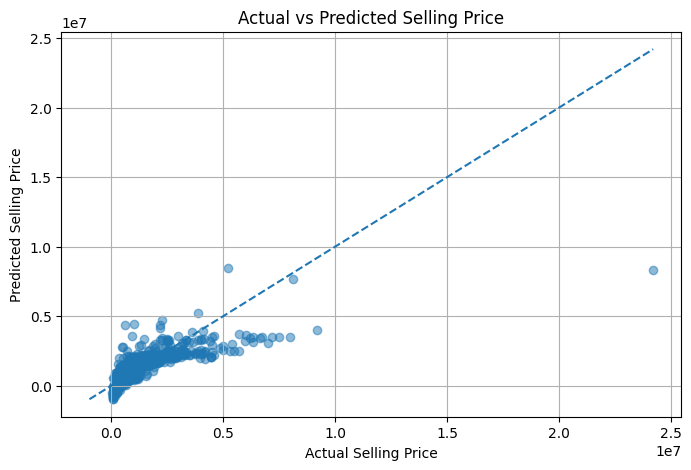

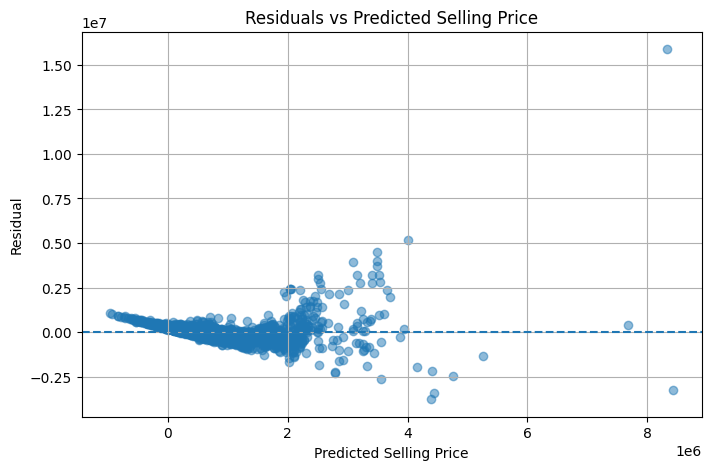

Observations with the 10 Largest Prediction Errors:


,Observation,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
0,2796,"₹24,200,000","₹8,323,205","₹15,876,795","₹15,876,795"
1,2362,"₹9,200,000","₹4,009,019","₹5,190,981","₹5,190,981"
2,1382,"₹8,000,000","₹3,488,917","₹4,511,083","₹4,511,083"
3,841,"₹7,500,000","₹3,485,714","₹4,014,286","₹4,014,286"
4,246,"₹7,000,000","₹3,084,722","₹3,915,278","₹3,915,278"
5,26,"₹625,000","₹4,390,874","₹-3,765,874","₹3,765,874"
6,1286,"₹7,199,000","₹3,488,917","₹3,710,083","₹3,710,083"
7,2528,"₹999,000","₹4,439,605","₹-3,440,605","₹3,440,605"
8,2050,"₹5,200,000","₹8,434,193","₹-3,234,193","₹3,234,193"
9,1092,"₹6,645,000","₹3,412,468","₹3,232,532","₹3,232,532"


In [42]:
# Plot Actual Selling Price versus Predicted Selling Price
plt.figure(figsize=(8, 5))

plt.scatter(ytest, y_pred, alpha=0.5)

# Create a reference line for perfect prediction
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.grid(True)
plt.show()


# Calculate residuals
residuals = ytest - y_pred

# Plot residuals against predicted values
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.5)

# Add a zero-error reference line
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Selling Price")
plt.grid(True)
plt.show()


# Calculate absolute prediction errors
absolute_errors = np.abs(residuals)

# Find the 10 observations with the largest errors
large_error_indices = np.argsort(absolute_errors)[-10:][::-1]

# Create a table of observations with large errors
large_error_table = pd.DataFrame({
    "Observation": large_error_indices,
    "Actual Selling Price": ytest[large_error_indices],
    "Predicted Selling Price": y_pred[large_error_indices],
    "Residual": residuals[large_error_indices],
    "Absolute Error": absolute_errors[large_error_indices]
})

# Format monetary values using ₹ and commas
large_error_table["Actual Selling Price"] = large_error_table[
    "Actual Selling Price"
].apply(lambda x: f"₹{x:,.0f}")

large_error_table["Predicted Selling Price"] = large_error_table[
    "Predicted Selling Price"
].apply(lambda x: f"₹{x:,.0f}")

large_error_table["Residual"] = large_error_table[
    "Residual"
].apply(lambda x: f"₹{x:,.0f}")

large_error_table["Absolute Error"] = large_error_table[
    "Absolute Error"
].apply(lambda x: f"₹{x:,.0f}")

print("Observations with the 10 Largest Prediction Errors:")
display(large_error_table)

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


### Conclusion
The Multiple Linear Regression model was successfully implemented using NumPy matrix operations and the Ordinary Least Squares (OLS) method. The selected features such as vehicle age, kilometers driven, mileage, engine, maximum power, seats, and categorical variables were used to predict the selling price of used cars.

The most influential features can be identified from the regression coefficients. Features with larger standardized coefficient magnitudes have a greater influence on the predicted selling price, while the sign of the coefficient indicates whether the feature increases or decreases the predicted price, keeping other features constant.

Advantages:

Simple and easy to understand and implement.
Shows the relationship between multiple features and selling price.
Provides interpretable regression coefficients.
Computationally efficient for a moderate-sized dataset.
Allows the effect of individual features to be studied.

Limitations:

Assumes a linear relationship between features and selling price.
Sensitive to outliers, which can affect the regression coefficients.
Prediction accuracy depends on the quality and selection of features.
Important factors such as brand, model, vehicle condition, location, and market demand may not be included.
Multicollinearity between predictors can affect the reliability of coefficients.
It may not capture complex non-linear relationships in used-car prices.

Overall, Multiple Linear Regression provides a simple and interpretable approach for used-car price prediction, but its performance is limited when the relationship between vehicle features and price is complex or when important influencing factors are missing.